In [357]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [358]:
df=sns.load_dataset('iris')

In [359]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [360]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv('pima-indians-diabetes.csv', names=columns)



In [361]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [362]:
duplicates = df.duplicated()
print("Số dòng trùng lặp:", duplicates.sum())

df_cleaned = df.drop_duplicates()
print("Số dòng sau khi loại bỏ trùng lặp:", df_cleaned.shape)

Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: (768, 9)


In [363]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (40, 200),
    'BloodPressure': (20, 140),
    'SkinThickness': (5, 99),
    'Insulin': (15, 846),
    'BMI': (15, 60),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (10, 100)
}

In [364]:
def detect_physiological_errors(df, physiological_ranges):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('df must be a pandas DataFrame')
    if not isinstance(physiological_ranges, dict):
        raise TypeError('physiological_ranges must be a dict')
    errors = {}
    for col, valid_range in physiological_ranges.items():
        if col not in df.columns:
            continue
        if not (isinstance(valid_range, (tuple, list)) and len(valid_range) == 2):
            raise ValueError(f'Range for {col} must be tuple/list (min, max)')
        min_val, max_val = valid_range
        col_values = df[col]
        invalid_mask = col_values.notna() & ((col_values < min_val) | (col_values > max_val))
        invalid_values = col_values[invalid_mask]
        if not invalid_values.empty:
            errors[col] = {
                'count': int(invalid_values.shape[0]),
                'min_actual': float(col_values.min()) if pd.notna(col_values.min()) else None,
                'max_actual': float(col_values.max()) if pd.notna(col_values.max()) else None,
                'problem_values': sorted(set(invalid_values.tolist()))
            }
    return errors

In [365]:
errors = detect_physiological_errors(df, physiological_ranges)
print("=== Dữ liệu lỗi phát hiện ===")
for col, info in errors.items():
        print(f"{col}: {info['count']} giá trị lỗi")
        print(f" -Range thực tế: {info['min_actual']} - {info['max_actual']}")
        print(f" -Giá trị có vấn đề: {info['problem_values']}")

=== Dữ liệu lỗi phát hiện ===
Glucose: 5 giá trị lỗi
 -Range thực tế: 0.0 - 199.0
 -Giá trị có vấn đề: [0]
BloodPressure: 35 giá trị lỗi
 -Range thực tế: 0.0 - 122.0
 -Giá trị có vấn đề: [0]
SkinThickness: 227 giá trị lỗi
 -Range thực tế: 0.0 - 99.0
 -Giá trị có vấn đề: [0]
Insulin: 375 giá trị lỗi
 -Range thực tế: 0.0 - 846.0
 -Giá trị có vấn đề: [0, 14]
BMI: 12 giá trị lỗi
 -Range thực tế: 0.0 - 67.1
 -Giá trị có vấn đề: [0.0, 67.1]


In [366]:

def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")
            median_val = df[col][df[col] > 0].median()
            df.loc[zero_mask, col] = median_val
            print(f" -> Đã thay thế bằng median: {median_val:.2f}")
    return df
df_final = handle_zero_values(df_cleaned)

Phát hiện 374 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


In [367]:
for col, (min_val, max_val) in physiological_ranges.items():
    df_final = df_final[(df_final[col] >= min_val) & (df_final[col] <= max_val)]

print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")

final_errors = detect_physiological_errors(df_final, physiological_ranges)

if not final_errors:
    print("Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 722 dòng
Tỷ lệ giữ lại: 94.0%
Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý


In [368]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


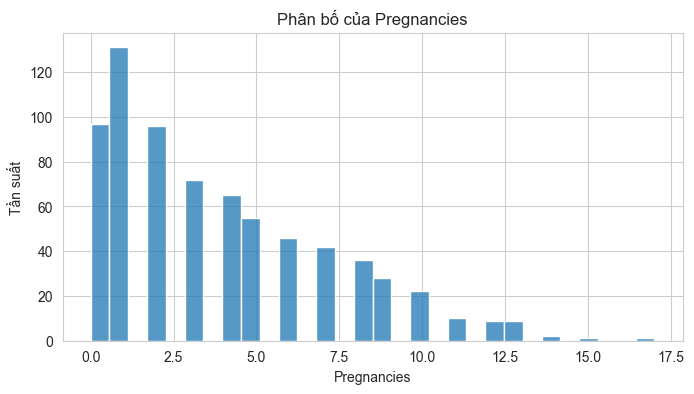

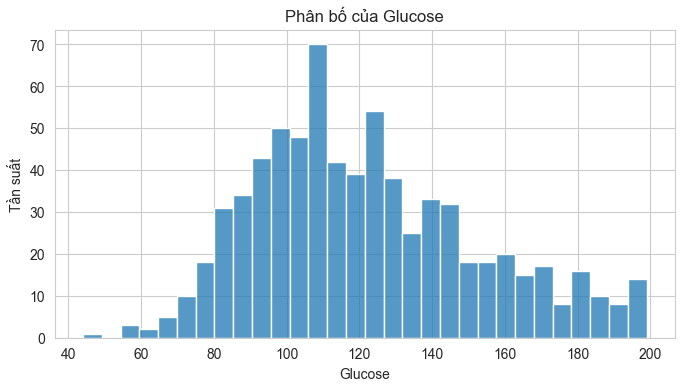

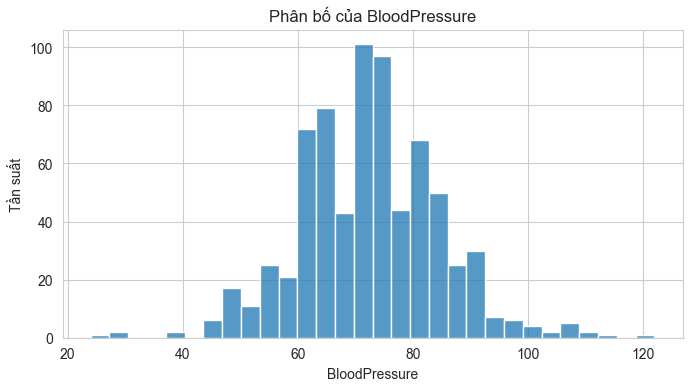

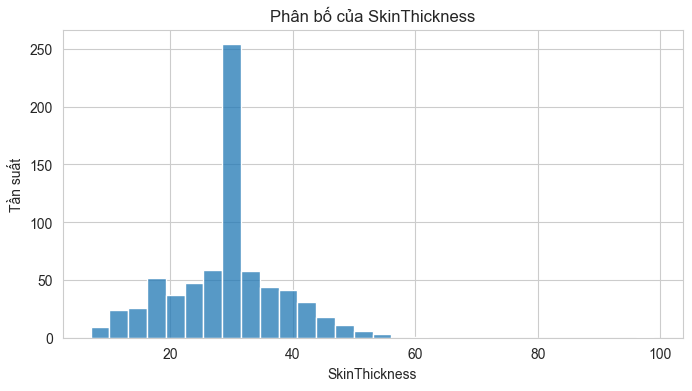

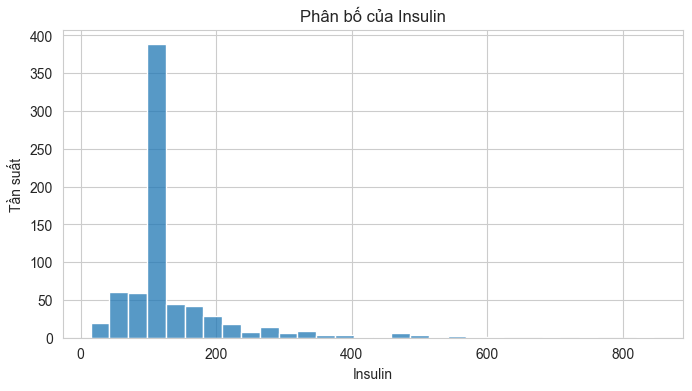

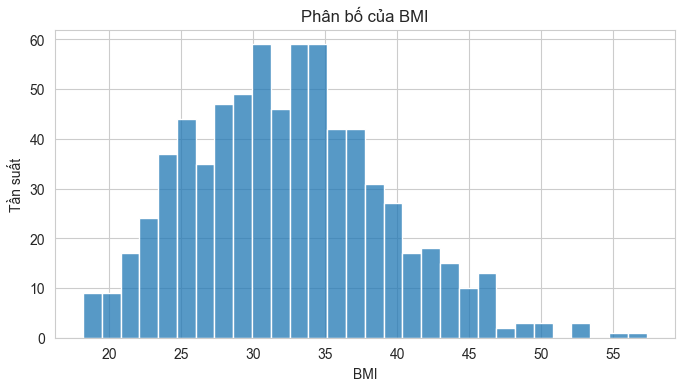

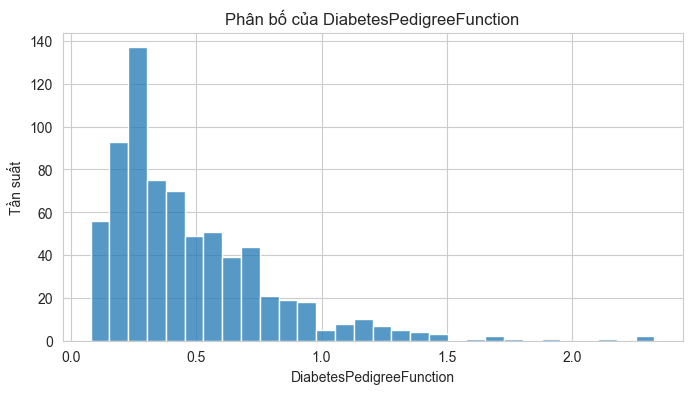

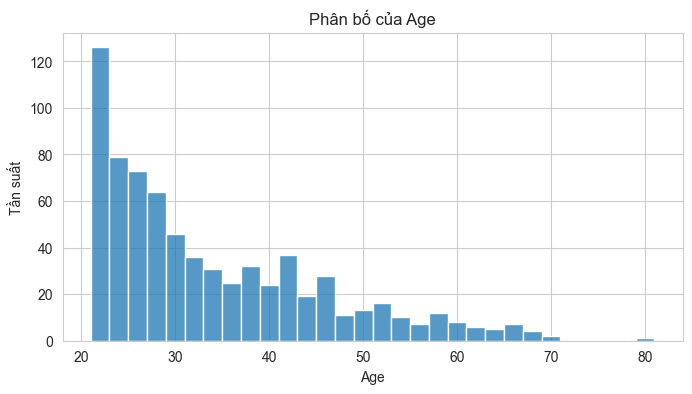

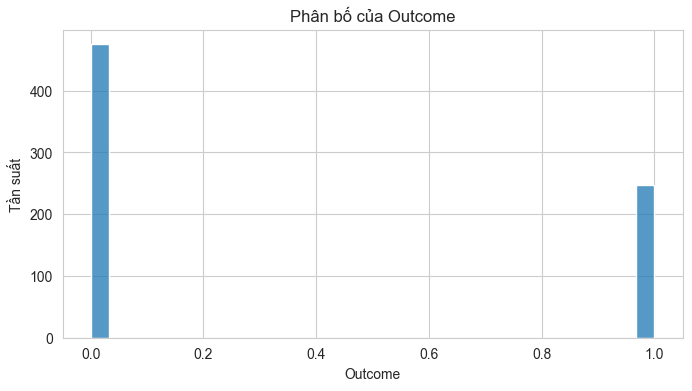

In [369]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df_final.columns:
    plt.figure(figsize=(8,4))
    
    if df_final[column].dtype in ['int64', 'float64']:
        sns.histplot(data=df_final, x=column, bins=30)
        plt.ylabel("Tần suất")

    else:
        sns.countplot(data=df_final, x=column)
        plt.ylabel("Số lượng")
    
    plt.title(f"Phân bố của {column}")
    plt.xlabel(column)
    plt.show()

=== PHÁT HIỆN OUTLIERS BẰNG IQR ===
Pregnancies: 4 outliers
  - Giới hạn dưới: -6.50, Giới hạn trên: 13.50
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(17)]...

Glucose: 0 outliers

BloodPressure: 13 outliers
  - Giới hạn dưới: 40.00, Giới hạn trên: 104.00
  - Giá trị outliers: [np.int64(24), np.int64(30), np.int64(38), np.int64(106), np.int64(108), np.int64(110), np.int64(114), np.int64(122)]...

SkinThickness: 51 outliers
  - Giới hạn dưới: 13.00, Giới hạn trên: 45.00
  - Giá trị outliers: [np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]...

Insulin: 303 outliers
  - Giới hạn dưới: 100.88, Giới hạn trên: 149.88
  - Giá trị outliers: [np.int64(15), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(29), np.int64(32), np.int64(36), np.int64(37)]...

BMI: 5 outliers
  - Giới hạn dưới: 13.85, Giới hạn trên: 50.25
  - Giá trị outliers: [np.float64(52.3), np.

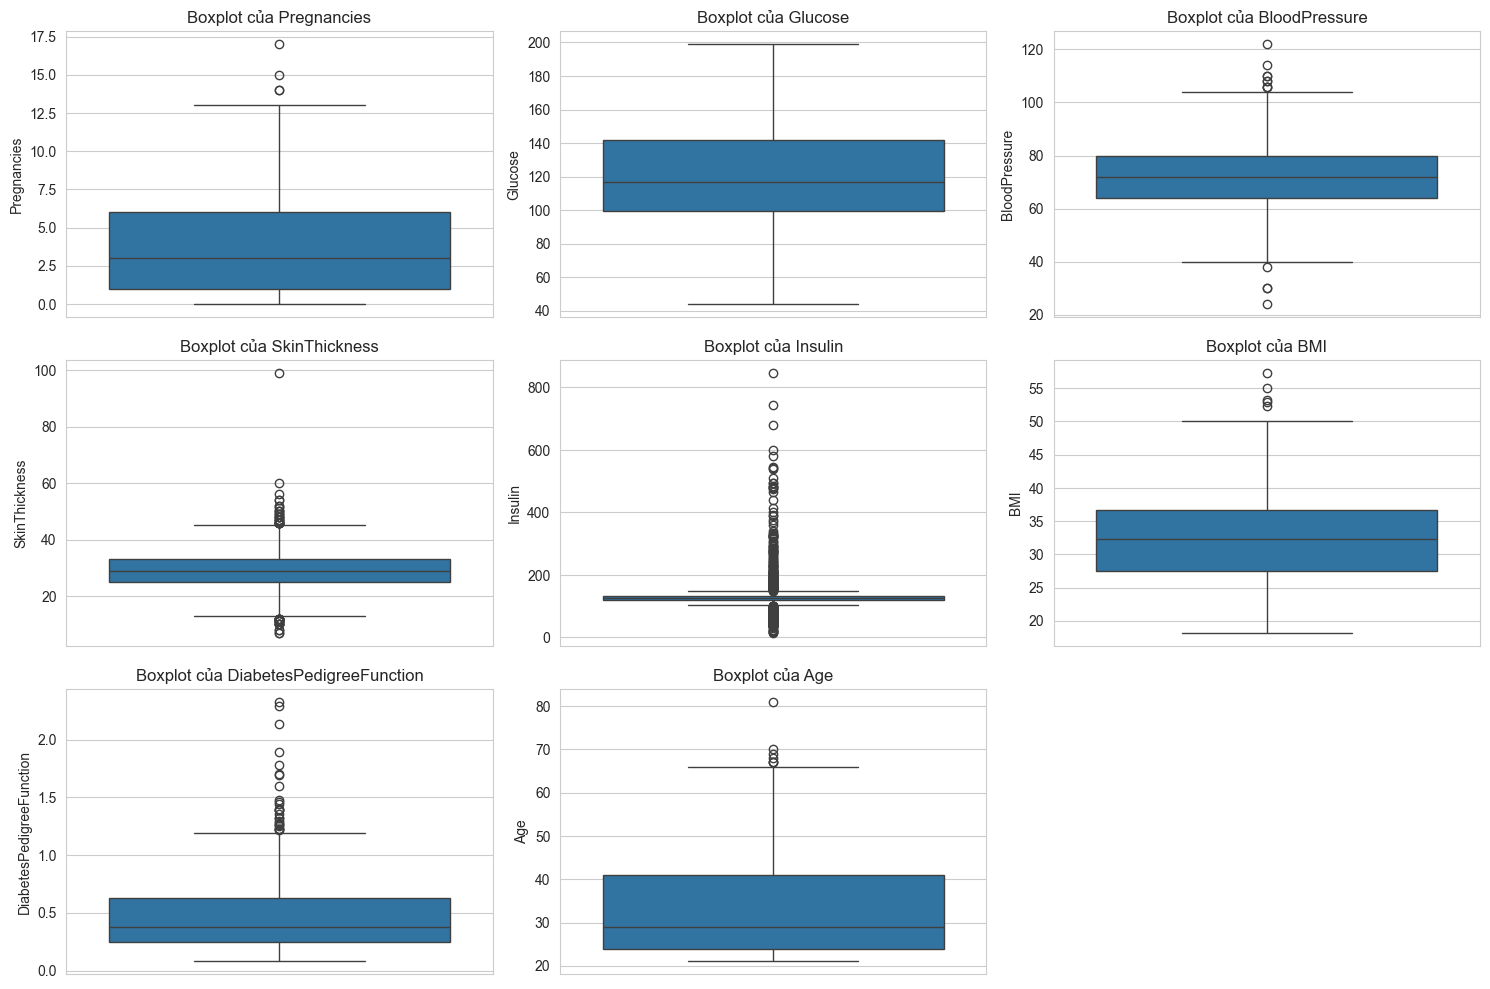

In [370]:
import numpy as np
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
print("=== PHÁT HIỆN OUTLIERS BẰNG IQR ===")
numeric_columns = df_final.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col != 'Outcome':  
        outliers, lower, upper = detect_outliers_iqr(df_final, col)
        print(f"{col}: {len(outliers)} outliers")
        if len(outliers) > 0:
            print(f"  - Giới hạn dưới: {lower:.2f}, Giới hạn trên: {upper:.2f}")
            print(f"  - Giá trị outliers: {sorted(outliers[col].unique())[:10]}...")  
        print()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    if col != 'Outcome':
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df_final[col])
        plt.title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

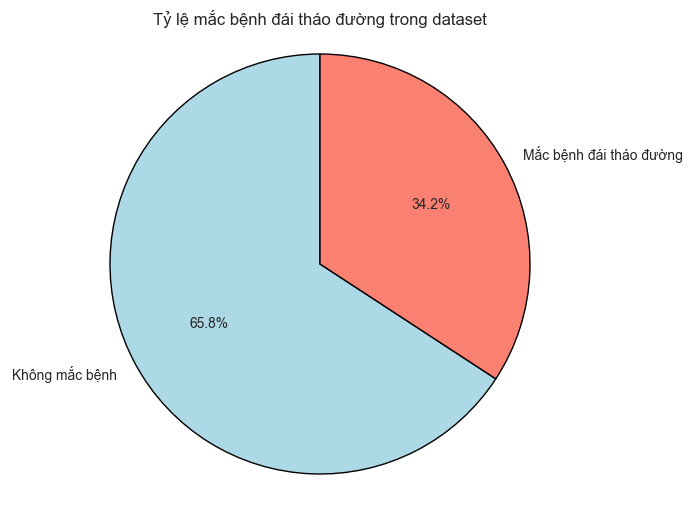

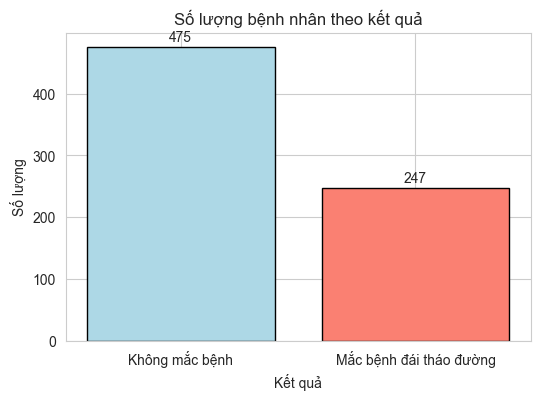

In [371]:
outcome_counts = df_final['Outcome'].value_counts()
labels = ['Không mắc bệnh', 'Mắc bệnh đái tháo đường']
colors = ['lightblue', 'salmon']
plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ mắc bệnh đái tháo đường trong dataset')
plt.axis('equal') 
plt.show()
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, outcome_counts.values, color=colors, edgecolor='black')
plt.title('Số lượng bệnh nhân theo kết quả')
plt.ylabel('Số lượng')
plt.xlabel('Kết quả')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', va='bottom')
plt.show()

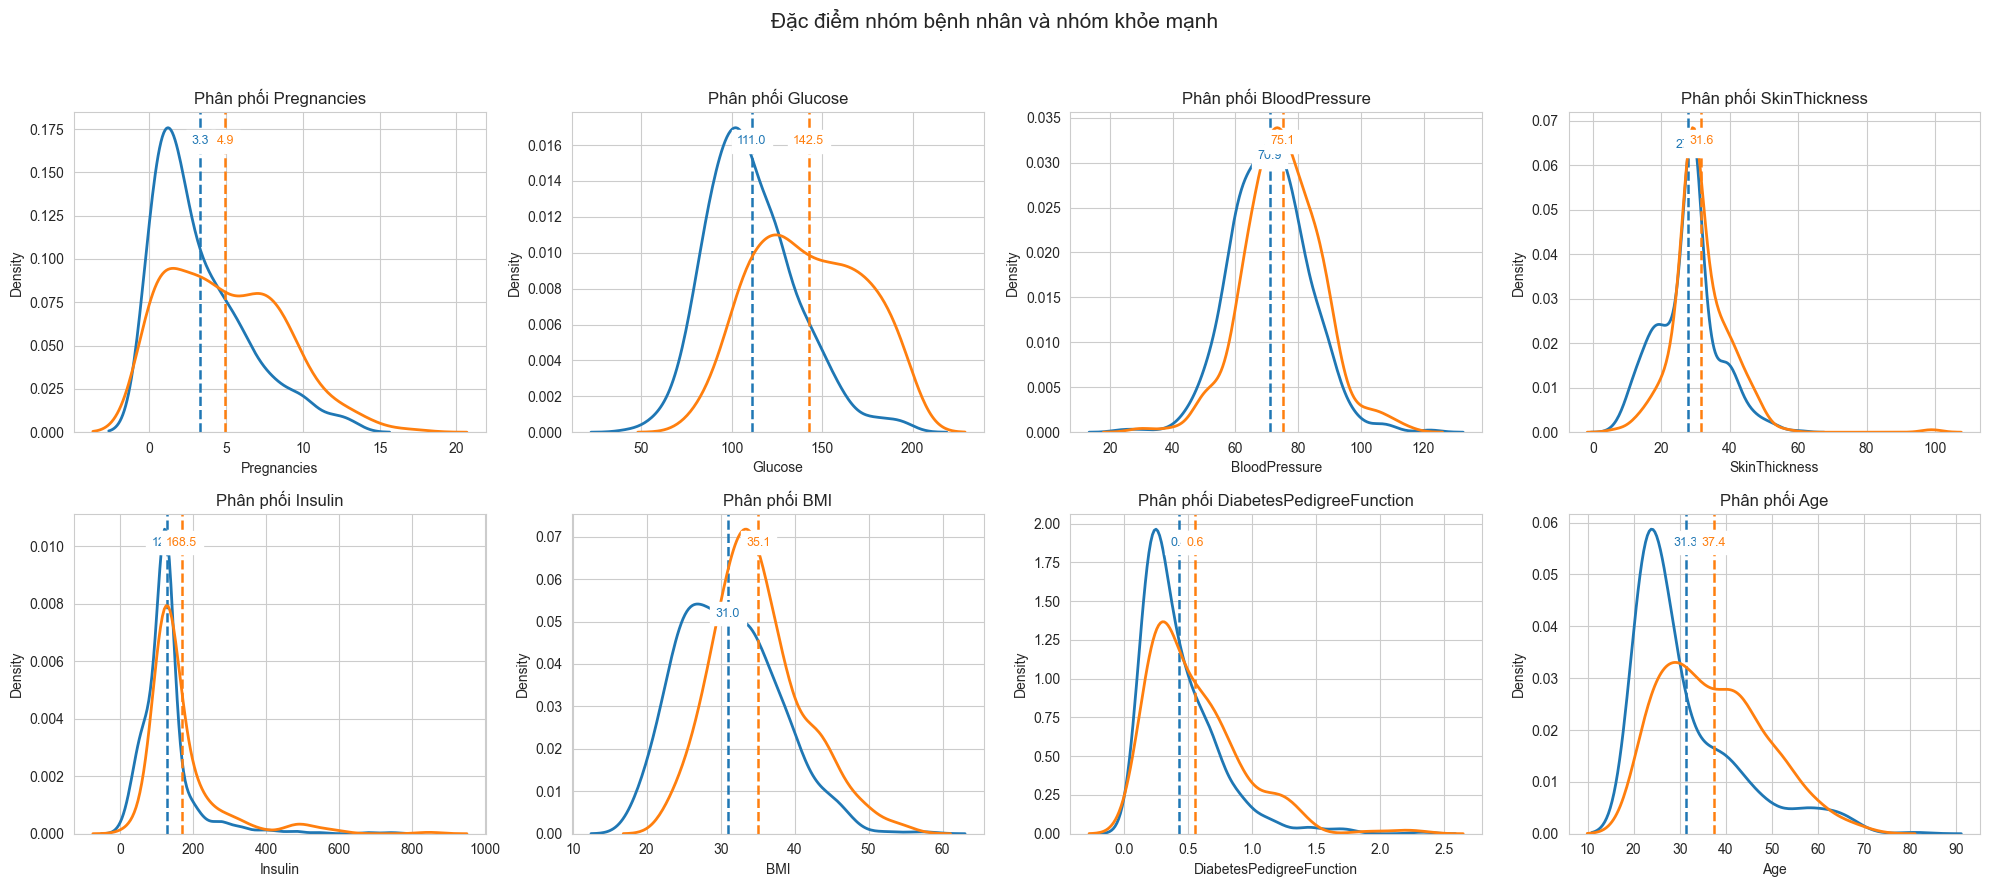

In [372]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_final.copy()
df_plot['Group'] = df_plot['Outcome'].map({0: 'Không mắc', 1: 'Mắc'})

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

sns.set_style("whitegrid")

fig, axes = plt.subplots(2,4, figsize=(20,9))
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e']

for i, col in enumerate(features):
    ax = axes[i]

    for group, color in zip(['Không mắc', 'Mắc'], colors):

        subset = df_plot[df_plot['Group'] == group]

        sns.kdeplot(
            data=subset,
            x=col,
            linewidth=2,
            color=color,
            ax=ax
        )

        mean_val = subset[col].mean()
        ax.axvline(mean_val,
                   color=color,
                   linestyle='--',
                   linewidth=1.8)

        ax.text(mean_val,
                ax.get_ylim()[1]*0.9,
                f"{mean_val:.1f}",
                color=color,
                fontsize=9,
                ha='center',
                backgroundcolor='white')

    ax.set_title(f'Phân phối {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh', fontsize=15)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

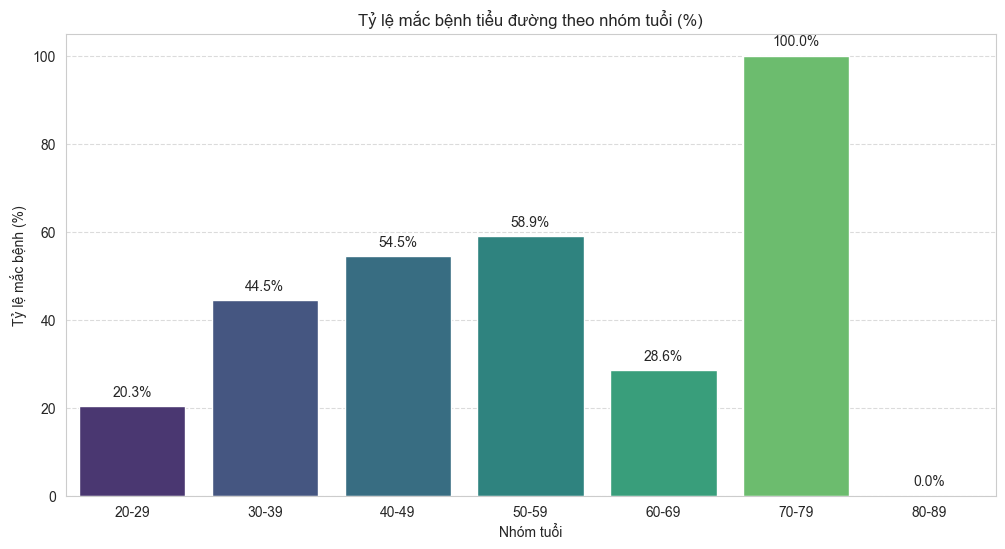

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_plot = df_final.copy()

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)

age_disease_rate = df_plot.groupby('Age_Group')['Outcome'].mean().reset_index()
age_disease_rate['Outcome'] *= 100

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Outcome',
    palette='viridis'
)

plt.title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,5),
                textcoords='offset points')

plt.show()

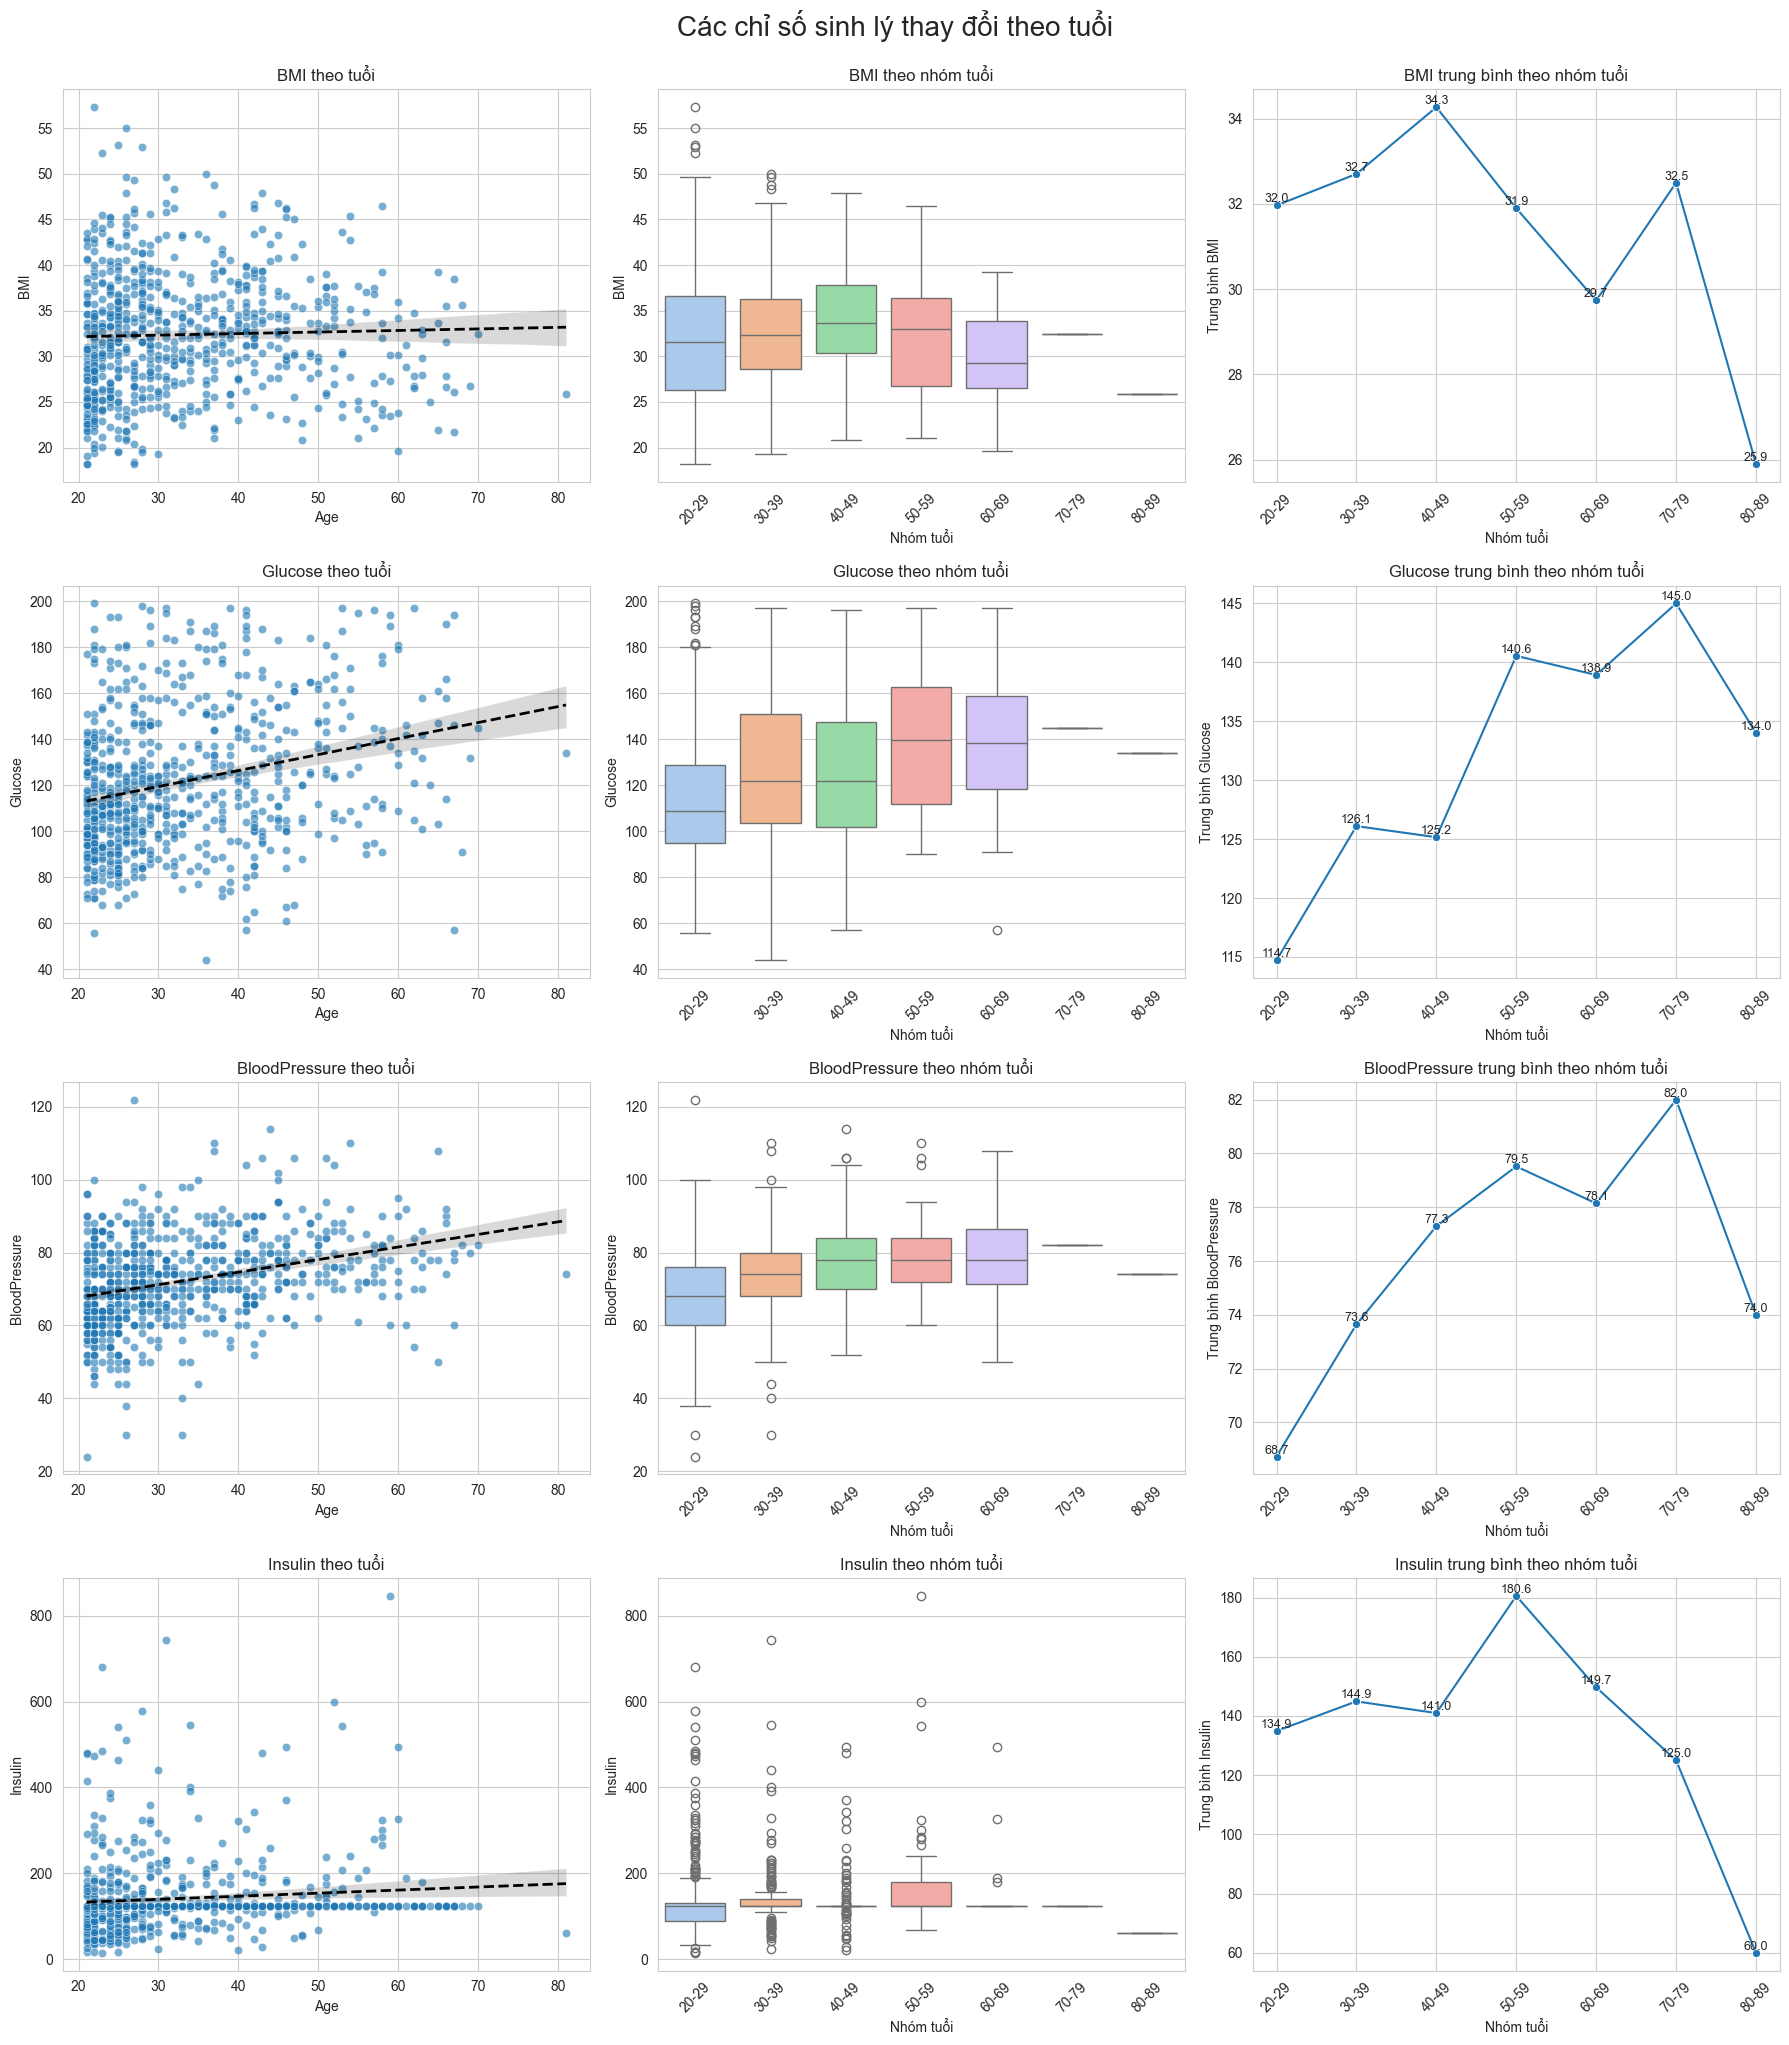

In [374]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_plot = df_final.copy()

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)

features = ['BMI', 'Glucose', 'BloodPressure', 'Insulin']

sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):

    # Scatter + trendline
    ax = axes[i*3]
    sns.scatterplot(data=df_plot, x='Age', y=feat, alpha=0.6, ax=ax)
    sns.regplot(data=df_plot, x='Age', y=feat, scatter=False,
                line_kws={'color':'black','lw':2,'ls':'--'}, ax=ax)

    ax.set_title(f'{feat} theo tuổi')
    ax.set_xlabel('Age')
    ax.set_ylabel(feat)

    # Boxplot theo nhóm tuổi
    ax = axes[i*3 + 1]
    sns.boxplot(data=df_plot, x='Age_Group', y=feat, palette='pastel', ax=ax)

    ax.set_title(f'{feat} theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=45)

    # Trung bình theo nhóm tuổi
    avg = df_plot.groupby('Age_Group')[feat].mean().reset_index()

    ax = axes[i*3 + 2]
    sns.lineplot(data=avg, x='Age_Group', y=feat, marker='o', ax=ax)

    ax.set_title(f'{feat} trung bình theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(f'Trung bình {feat}')
    ax.tick_params(axis='x', rotation=45)

    for x, y in zip(avg['Age_Group'], avg[feat]):
        ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Các chỉ số sinh lý thay đổi theo tuổi', fontsize=20, y=1.02)
plt.show()

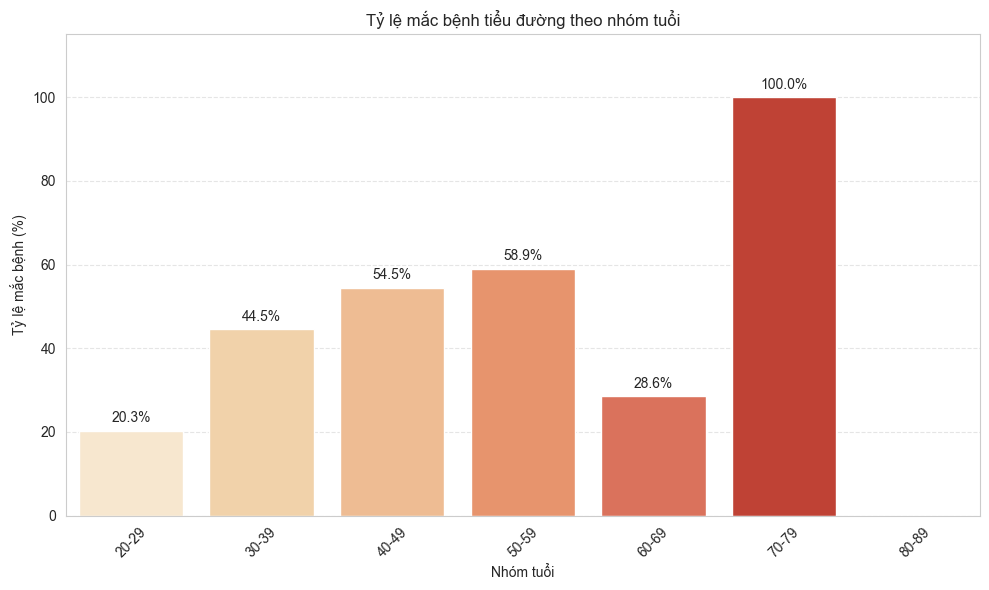

In [375]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df_final.copy()

# Nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

df_plot['Age_Group'] = pd.cut(df_plot['Age'], bins=bins, labels=labels, right=False)

# Tỷ lệ mắc bệnh theo nhóm tuổi
age_disease_rate = (
    df_plot.groupby('Age_Group')['Outcome']
    .mean()
    .reset_index(name='Diabetes_Rate')
)

age_disease_rate['Diabetes_Rate'] *= 100

age_disease_rate = age_disease_rate.dropna()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Diabetes_Rate',
    palette='OrRd'
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom',
                    xytext=(0,4),
                    textcoords='offset points')

ax.set_title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Tỷ lệ mắc bệnh (%)')

ax.set_ylim(0, age_disease_rate['Diabetes_Rate'].max()*1.15)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

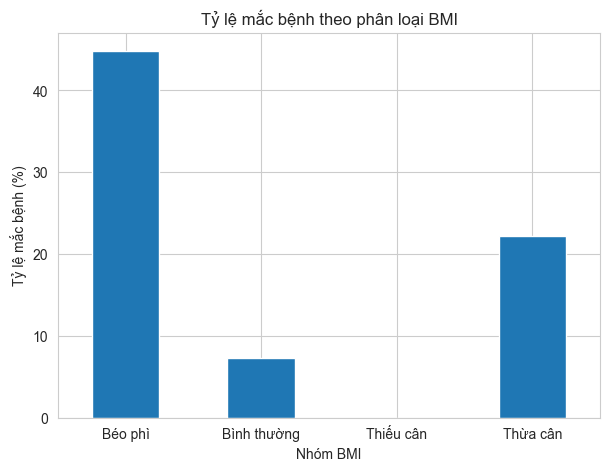

In [376]:
import pandas as pd
import matplotlib.pyplot as plt


def bmi_category(bmi):
    if bmi < 18.5:
        return "Thiếu cân"
    elif bmi < 25:
        return "Bình thường"
    elif bmi < 30:
        return "Thừa cân"
    else:
        return "Béo phì"

df_final['BMI_Category'] = df_final['BMI'].apply(bmi_category)


bmi_outcome = df_final.groupby('BMI_Category')['Outcome'].mean() * 100


plt.figure(figsize=(7,5))
bmi_outcome.plot(kind='bar')

plt.title("Tỷ lệ mắc bệnh theo phân loại BMI")
plt.xlabel("Nhóm BMI")
plt.ylabel("Tỷ lệ mắc bệnh (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
import pandas as pd

column_bmi = 'BMI'
column_outcome = 'Outcome'


df_final = df_final[df_final[column_bmi] > 0]

bins = [0, 18.5, 25, 30, 100]
labels = ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì']

df_final['Nhóm BMI'] = pd.cut(df_final[column_bmi], bins=bins, labels=labels, right=False)

summary_table = df_final.groupby('Nhóm BMI').agg(
    Tong_so=(column_outcome, 'count'),
    So_ca_mac=(column_outcome, 'sum'),
    BMI_trung_binh=(column_bmi, 'mean')
).reset_index()

summary_table['Tỷ lệ mắc (%)'] = (
    summary_table['So_ca_mac'] / summary_table['Tong_so'] * 100
).round(1).astype(str) + '%'

summary_table['BMI_trung_binh'] = summary_table['BMI_trung_binh'].round(1)

summary_table = summary_table[['Nhóm BMI','Tong_so','So_ca_mac','Tỷ lệ mắc (%)','BMI_trung_binh']]

summary_table.columns = ['Nhóm BMI', 'Tổng số', 'Số ca mắc', 'Tỷ lệ mắc (%)', 'BMI trung bình']

print(summary_table)

      Nhóm BMI  Tổng số  Số ca mắc Tỷ lệ mắc (%)  BMI trung bình
0          Gầy        4          0          0.0%            18.2
1  Bình thường       96          7          7.3%            22.8
2     Thừa cân      171         38         22.2%            27.5
3      Béo phì      451        202         44.8%            36.4
